In [3]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import time
import math
from numba import cuda

BLOCK_SIZE = 16

img = mpimg.imread('original_image.jpg')
height, width, channels = img.shape
grid_size = (
        (width + BLOCK_SIZE - 1) // BLOCK_SIZE,
        (height + BLOCK_SIZE - 1) // BLOCK_SIZE
    )
block_size = (BLOCK_SIZE, BLOCK_SIZE)
print("Image shape:", img.shape, "| grid:", grid_size, "| block:", block_size)

Image shape: (2160, 3840, 3) | grid: (240, 135) | block: (16, 16)


# Labwork 6a: Grayscale Binarization

Binarization time: 2.1619s


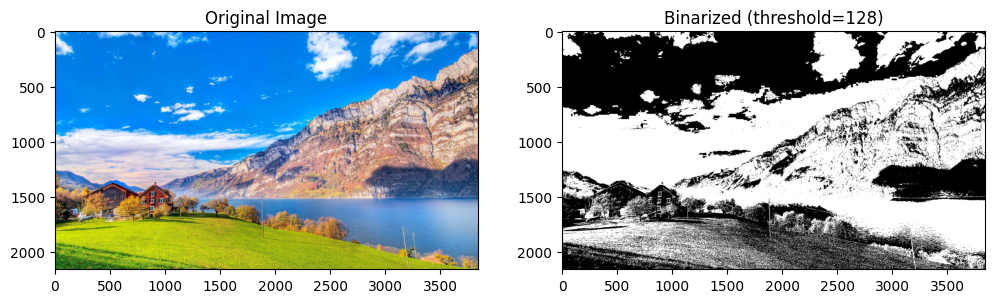

In [4]:
THRESHOLD = 128
@cuda.jit
def binarize_kernel(src, dst, threshold):
    x, y = cuda.grid(2)
    h, w, _ = src.shape
    if x < w and y < h:
        gray = (src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) / 3
        value = 255 if gray >= threshold else 0
        dst[y, x, 0] = value
        dst[y, x, 1] = value
        dst[y, x, 2] = value


start = time.time()
d_src = cuda.to_device(img)
d_dst = cuda.device_array_like(img)

binarize_kernel[grid_size, block_size](d_src, d_dst, THRESHOLD)
cuda.synchronize()

binarized = d_dst.copy_to_host()
print(f"Binarization time: {time.time() - start:.4f}s")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(binarized)
plt.title(f"Binarized (threshold={THRESHOLD})")
plt.show()

# Labwork 6b: Brightness Control

Brightness control time: 0.1451s


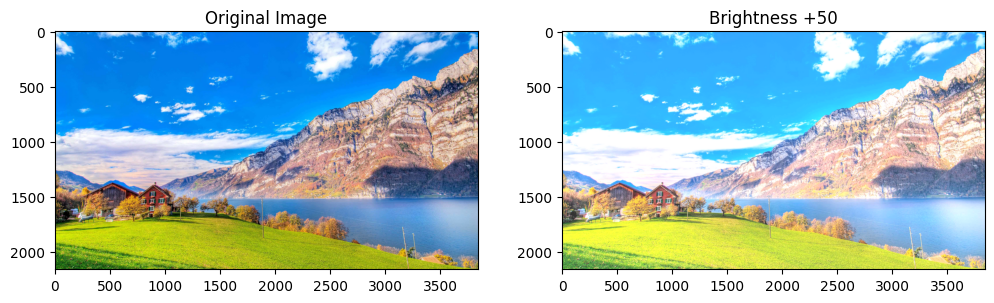

In [5]:
BRIGHTNESS = 50


@cuda.jit
def brightness_kernel(src, dst, brightness):
    x, y = cuda.grid(2)
    h, w, c = src.shape
    if x < w and y < h:
        for ch in range(c):
            value = src[y, x, ch] + brightness
            dst[y, x, ch] = min(max(value, 0), 255)


start = time.time()
d_src = cuda.to_device(img)
d_dst = cuda.device_array_like(img)

brightness_kernel[grid_size, block_size](d_src, d_dst, BRIGHTNESS)
cuda.synchronize()

brightened = d_dst.copy_to_host()
print(f"Brightness control time: {time.time() - start:.4f}s")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(brightened)
plt.title(f"Brightness {'+' if BRIGHTNESS >= 0 else ''}{BRIGHTNESS}")
plt.show()

# Labwork 6c: Blending Two Images

Blending time: 0.2114s


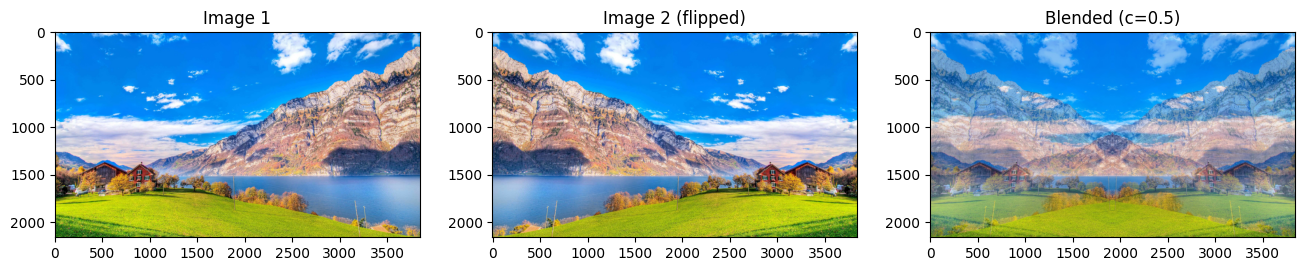

In [7]:
COEFF = 0.5  # weight of image 1; image 2 gets (1 - COEFF)

img2 = np.fliplr(img)


@cuda.jit
def blend_kernel(src1, src2, dst, coeff):
    x, y = cuda.grid(2)
    h, w, c = src1.shape
    if x < w and y < h:
        for ch in range(c):
            dst[y, x, ch] = coeff * src1[y, x, ch] + (1 - coeff) * src2[y, x, ch]


start = time.time()
d_src1 = cuda.to_device(img)
d_src2 = cuda.to_device(np.array(img2))
d_dst = cuda.device_array_like(img)

blend_kernel[grid_size, block_size](d_src1, d_src2, d_dst, COEFF)
cuda.synchronize()

blended = d_dst.copy_to_host()
print(f"Blending time: {time.time() - start:.4f}s")

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Image 1")
plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.title("Image 2 (flipped)")
plt.subplot(1, 3, 3)
plt.imshow(blended)
plt.title(f"Blended (c={COEFF})")
plt.show()